# Volatility Risk Premium Timing of an SPX PutWrite Strategy

This project investigates whether the gap between implied and realized equity volatility can be used to identify more attractive regimes for systematic option selling.

The analysis constructs a volatility risk premium signal using VIX as a proxy for implied volatility and realized volatility calculated from S&P 500 returns. The signal is then used to study and time the performance of an SPX put-writing strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Merge Market Data

Daily S&P 500 and VIX data are used to construct the volatility risk premium signal. The two series are cleaned, aligned by date, and restricted to common observations.

In [2]:
sp500 = pd.read_csv("SP500.csv")
vix = pd.read_csv("VIXCLS.csv")

sp500.head(), vix.head()

(  observation_date    SP500
 0       2016-09-06  2186.48
 1       2016-09-07  2186.16
 2       2016-09-08  2181.30
 3       2016-09-09  2127.81
 4       2016-09-12  2159.04,
   observation_date  VIXCLS
 0       1990-01-02   17.24
 1       1990-01-03   18.19
 2       1990-01-04   19.22
 3       1990-01-05   20.11
 4       1990-01-08   20.26)

In [3]:
sp500["observation_date"] = pd.to_datetime(sp500["observation_date"])
vix["observation_date"] = pd.to_datetime(vix["observation_date"])

In [4]:
sp500 = sp500.rename(columns={
    "observation_date": "date",
    "SP500": "sp500"
})

vix = vix.rename(columns={
    "observation_date": "date",
    "VIXCLS": "vix"
})

In [5]:
data = pd.merge(
    sp500,
    vix,
    on="date",
    how="inner"
)

data.head()

,date,sp500,vix
0,2016-09-06,2186.48,12.02
1,2016-09-07,2186.16,11.94
2,2016-09-08,2181.30,12.51
3,2016-09-09,2127.81,17.50
4,2016-09-12,2159.04,15.16


In [6]:
data = data.dropna().copy()

In [7]:
data = data.sort_values("date").reset_index(drop=True)

## 2. Construct Realized Volatility

Daily S&P 500 log returns are used to estimate 21-day realized volatility. The rolling standard deviation is annualized using 252 trading days and expressed in percentage points so it is directly comparable with VIX.

In [8]:
data["log_return"] = np.log(
    data["sp500"] / data["sp500"].shift(1)
)

In [9]:
data["realized_vol"] = (
    data["log_return"]
    .rolling(window=21)
    .std()
    * np.sqrt(252)
    * 100
)

## 3. Build the Volatility Risk Premium Signal

The volatility risk premium is defined as the difference between implied volatility, proxied by VIX, and trailing realized volatility:

$$
VRP_t = VIX_t - RV_t
$$

A positive value indicates that implied volatility exceeds recently realized volatility.

In [10]:
data["vrp"] = data["vix"] - data["realized_vol"]

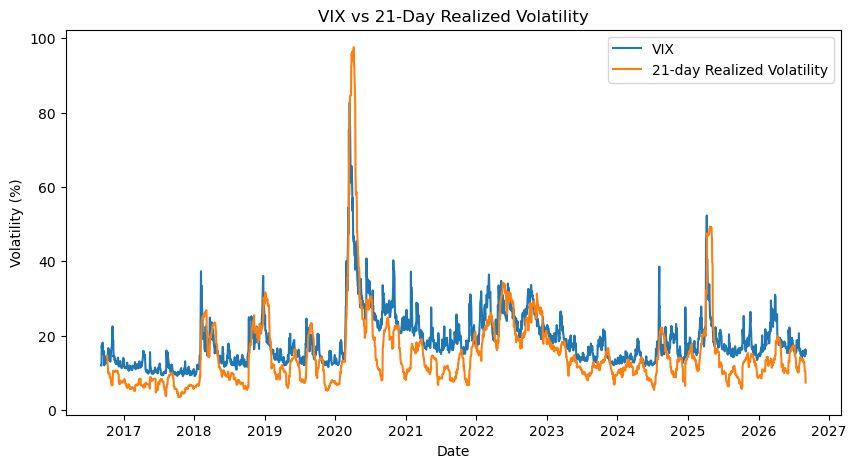

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(data["date"], data["vix"], label="VIX")
plt.plot(data["date"], data["realized_vol"], label="21-day Realized Volatility")

plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.title("VIX vs 21-Day Realized Volatility")
plt.legend()

plt.show()

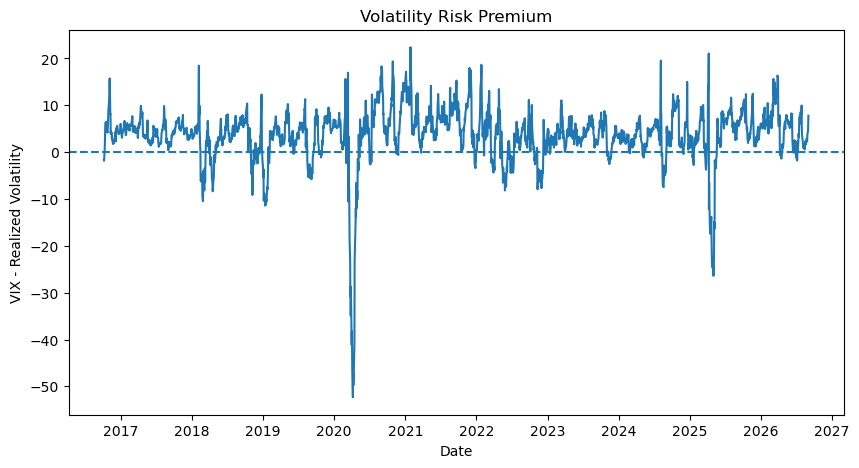

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(data["date"], data["vrp"])

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("VIX - Realized Volatility")
plt.title("Volatility Risk Premium")

plt.show()

In [13]:
data["vrp"].describe()

count    2491.000000
mean        3.642631
std         6.095697
min       -52.315150
25%         1.847679
50%         4.187092
75%         6.439569
max        22.407053
Name: vrp, dtype: float64

### Standardize the VRP Signal

A 252-day rolling z-score is used to measure how unusual the current volatility risk premium is relative to its recent one-year history.

In [14]:
rolling_mean = data["vrp"].rolling(252).mean()
rolling_std = data["vrp"].rolling(252).std()

data["vrp_zscore"] = (
    data["vrp"] - rolling_mean
) / rolling_std

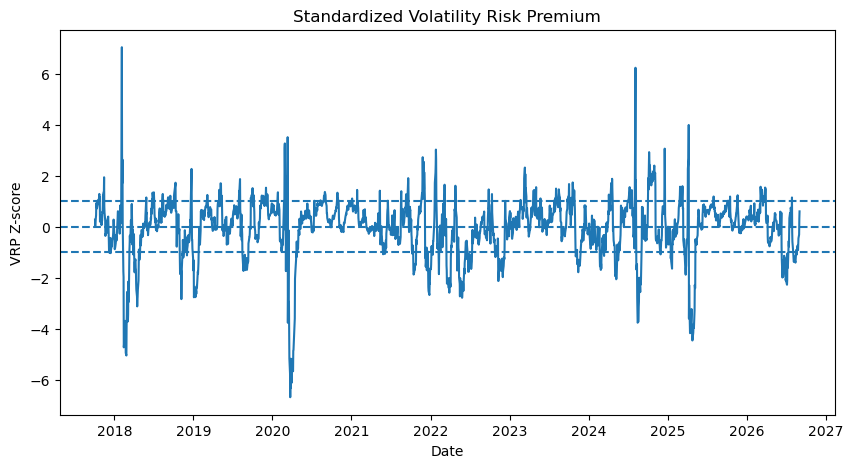

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(data["date"], data["vrp_zscore"])

plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")

plt.xlabel("Date")
plt.ylabel("VRP Z-score")
plt.title("Standardized Volatility Risk Premium")

plt.show()

## 4. Load the PutWrite Benchmark

The Cboe S&P 500 PutWrite Index is used as the return series for a systematic collateralized SPX put-selling strategy. The index is aligned with the VRP dataset by trading date.

In [16]:
put = pd.read_csv(
    "CBOE S&P 500 Putwrite Historical Results Price Data-2.csv"
)

In [17]:
put["Date"] = pd.to_datetime(
    put["Date"],
    dayfirst=True
)

put["Price"] = (
    put["Price"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [18]:
put = put[
    ["Date", "Price"]
].rename(columns={
    "Date": "date",
    "Price": "put_index"
})

In [19]:
put = put.sort_values("date").reset_index(drop=True)

In [20]:
data = pd.merge(
    data,
    put,
    on="date",
    how="inner"
)

In [21]:
data = data.sort_values("date").reset_index(drop=True)

## 5. Explore VRP Regimes

To test whether the signal contains useful information, the standardized VRP is divided into low, normal, and high regimes. Subsequent PutWrite returns are then compared across these regimes.

In [22]:
data["put_return"] = data["put_index"].pct_change()

In [23]:
data["next_day_put_return"] = data["put_return"].shift(-1)

In [24]:
data["vrp_regime"] = pd.cut(
    data["vrp_zscore"],
    bins=[-np.inf, -1, 1, np.inf],
    labels=["Low", "Normal", "High"]
)

In [25]:
regime_stats = (
    data
    .dropna(subset=["vrp_regime", "next_day_put_return"])
    .groupby("vrp_regime", observed=True)["next_day_put_return"]
    .agg(["count", "mean", "std"])
)

regime_stats["annualized_mean"] = regime_stats["mean"] * 252

regime_stats

,count,mean,std,annualized_mean
vrp_regime,,,,
Low,344,-0.000119,0.010947,-0.029918
Normal,1637,0.000203,0.006800,0.051046
High,258,0.001866,0.012875,0.470313


In [26]:
data["next_21d_put_return"] = (
    data["put_index"].shift(-21) / data["put_index"] - 1
)

In [27]:
data.groupby(
    "vrp_regime",
    observed=True
)["next_21d_put_return"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
vrp_regime,,,,
Low,334,0.008414,0.013673,0.028698
Normal,1627,0.005813,0.013226,0.032358
High,258,0.013332,0.018012,0.035963


## 6. Build the VRP-Timed PutWrite Strategy

The strategy holds the PutWrite index only when the VRP z-score exceeds 1.

The position is shifted by one trading day so that today's end-of-day signal determines tomorrow's exposure, avoiding look-ahead bias.

In [28]:
data["signal"] = (
    data["vrp_zscore"] > 1
).astype(int)

data["position"] = data["signal"].shift(1)

In [29]:
data["strategy_return"] = (
    data["position"] * data["put_return"]
)

In [30]:
cash = pd.read_csv("DGS3MO.csv")

cash["observation_date"] = pd.to_datetime(cash["observation_date"])

cash = cash.rename(columns={
    "observation_date": "date",
    "DGS3MO": "t_bill_rate"
})

In [31]:
data = data.merge(
    cash,
    on="date",
    how="left"
)

In [32]:
data["t_bill_rate"] = data["t_bill_rate"].ffill()

In [33]:
data["cash_return"] = (
    (1 + data["t_bill_rate"] / 100) ** (1 / 252) - 1
)

In [34]:
data["strategy_return_with_cash"] = (
    data["position"] * data["put_return"]
    + (1 - data["position"]) * data["cash_return"]
)

In [35]:
backtest = data.dropna(
    subset=[
        "put_return",
        "strategy_return",
        "strategy_return_with_cash",
        "vrp_zscore"
    ]
).copy()

In [36]:
backtest["put_cumulative"] = (
    1 + backtest["put_return"]
).cumprod()

backtest["strategy_cumulative"] = (
    1 + backtest["strategy_return"]
).cumprod()

backtest["strategy_cash_cumulative"] = (
    1 + backtest["strategy_return_with_cash"]
).cumprod()

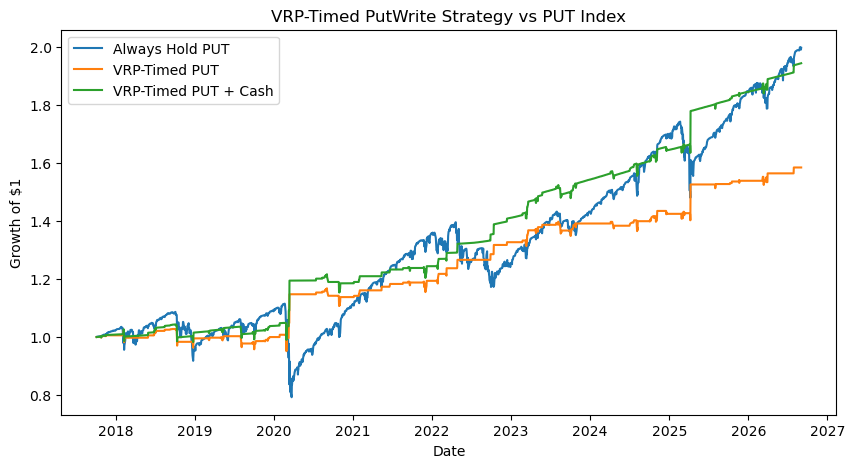

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    backtest["date"],
    backtest["put_cumulative"],
    label="Always Hold PUT"
)

plt.plot(
    backtest["date"],
    backtest["strategy_cumulative"],
    label="VRP-Timed PUT"
)

plt.plot(
    backtest["date"],
    backtest["strategy_cash_cumulative"],
    label="VRP-Timed PUT + Cash"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("VRP-Timed PutWrite Strategy vs PUT Index")
plt.legend()

plt.show()

## 7. Evaluate Strategy Performance

The VRP-timed strategy is compared with continuous PutWrite exposure using annualized return, volatility, Sharpe ratio, maximum drawdown, and market exposure.

In [38]:
def performance_stats(returns):
    returns = returns.dropna()

    annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol

    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Annualized Return": annual_return,
        "Annualized Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

In [39]:
backtest["put_drawdown"] = (
    backtest["put_cumulative"]
    / backtest["put_cumulative"].cummax()
    - 1
)

backtest["strategy_drawdown"] = (
    backtest["strategy_cumulative"]
    / backtest["strategy_cumulative"].cummax()
    - 1
)

backtest["strategy_cash_drawdown"] = (
    backtest["strategy_cash_cumulative"]
    / backtest["strategy_cash_cumulative"].cummax()
    - 1
)

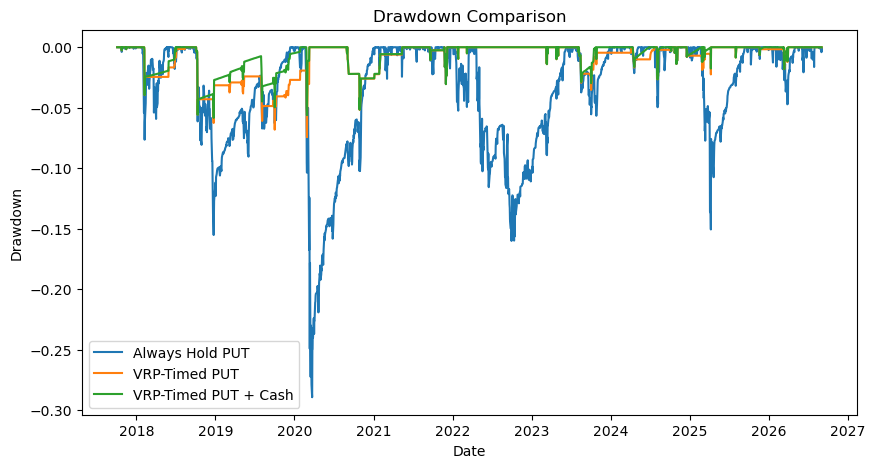

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    backtest["date"],
    backtest["put_drawdown"],
    label="Always Hold PUT"
)

plt.plot(
    backtest["date"],
    backtest["strategy_drawdown"],
    label="VRP-Timed PUT"
)

plt.plot(
    backtest["date"],
    backtest["strategy_cash_drawdown"],
    label="VRP-Timed PUT + Cash"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Drawdown Comparison")
plt.legend()

plt.show()

In [41]:
performance = pd.DataFrame({
    "Always Hold PUT": performance_stats(
        backtest["put_return"]
    ),
    "VRP-Timed PUT": performance_stats(
        backtest["strategy_return"]
    ),
    "VRP-Timed PUT + Cash": performance_stats(
        backtest["strategy_return_with_cash"]
    )
})

performance

,Always Hold PUT,VRP-Timed PUT,VRP-Timed PUT + Cash
Annualized Return,0.080917,0.053145,0.077641
Annualized Volatility,0.134217,0.069888,0.069828
Sharpe Ratio,0.602881,0.760432,1.111895
Max Drawdown,-0.289256,-0.074322,-0.058407


Including a 3-month Treasury cash return on idle capital materially improves the economics of the timing strategy.

The cash-adjusted strategy achieves an annualized return of approximately **7.76%**, compared with **5.31%** when idle capital is assumed to earn zero return. Annualized volatility remains close to **7.0%**, while the Sharpe ratio rises from approximately **0.76** to **1.11** and maximum drawdown improves from approximately **-7.4%** to **-5.8%**.

This indicates that the zero-return cash assumption was conservative, particularly because the strategy is invested in the PutWrite index on only a small fraction of trading days.

In [42]:
exposure = backtest["position"].mean()
exposure

np.float64(0.11517857142857142)

## 8. Random Same-Exposure Robustness Test

To test whether the strategy benefits simply from being invested less often, its performance is compared with randomly timed strategies that have approximately the same average market exposure.

A Monte Carlo simulation of 1,000 random timing strategies is used to assess where the VRP-timed strategy's Sharpe ratio lies within the random benchmark distribution.

In [43]:
np.random.seed(42)

target_exposure = backtest["position"].mean()


In [44]:
n_simulations = 1000

random_sharpes = []
random_returns = []
random_drawdowns = []

for _ in range(n_simulations):
    random_position = (
        np.random.rand(len(backtest)) < target_exposure
    ).astype(int)

    random_returns_series = (
        random_position * backtest["put_return"]
    )

    stats = performance_stats(random_returns_series)

    random_sharpes.append(stats["Sharpe Ratio"])
    random_returns.append(stats["Annualized Return"])
    random_drawdowns.append(stats["Max Drawdown"])

In [45]:
simulation_results = pd.DataFrame({
    "Annualized Return": random_returns,
    "Sharpe Ratio": random_sharpes,
    "Max Drawdown": random_drawdowns
})

simulation_results.describe()

,Annualized Return,Sharpe Ratio,Max Drawdown
count,1000.000000,1000.000000,1000.000000
mean,0.009394,0.231503,-0.114014
std,0.014269,0.329885,0.052846
min,-0.045873,-0.735695,-0.346918
25%,-0.000181,-0.003779,-0.145234
50%,0.009704,0.233428,-0.104035
75%,0.019103,0.458951,-0.073060
max,0.050110,1.351666,-0.031318


In [46]:
vrp_sharpe = performance.loc["Sharpe Ratio", "VRP-Timed PUT"]

percentile = (
    simulation_results["Sharpe Ratio"] < vrp_sharpe
).mean()

percentile

np.float64(0.941)

## 9. Threshold Sensitivity

The entry threshold is varied to assess whether the strategy is robust to reasonable changes in the VRP z-score cutoff rather than relying on a single parameter choice.

In [47]:
thresholds = [0.5, 0.75, 1.0, 1.25, 1.5]

threshold_results = []

for threshold in thresholds:
    signal = (backtest["vrp_zscore"] > threshold).astype(int)
    position = signal.shift(1).fillna(0)

    strategy_returns = position * backtest["put_return"]

    stats = performance_stats(strategy_returns)

    threshold_results.append({
        "Threshold": threshold,
        "Annualized Return": stats["Annualized Return"],
        "Annualized Volatility": stats["Annualized Volatility"],
        "Sharpe Ratio": stats["Sharpe Ratio"],
        "Max Drawdown": stats["Max Drawdown"],
        "Exposure": position.mean()
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,Threshold,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Exposure
0,0.50,0.057333,0.088209,0.649964,-0.089128,0.322768
1,0.75,0.047446,0.080307,0.590803,-0.165712,0.204018
2,1.00,0.053145,0.069888,0.760432,-0.074322,0.115179
3,1.25,0.057044,0.063298,0.901207,-0.060142,0.065179
4,1.50,0.049599,0.058339,0.850186,-0.076118,0.036161


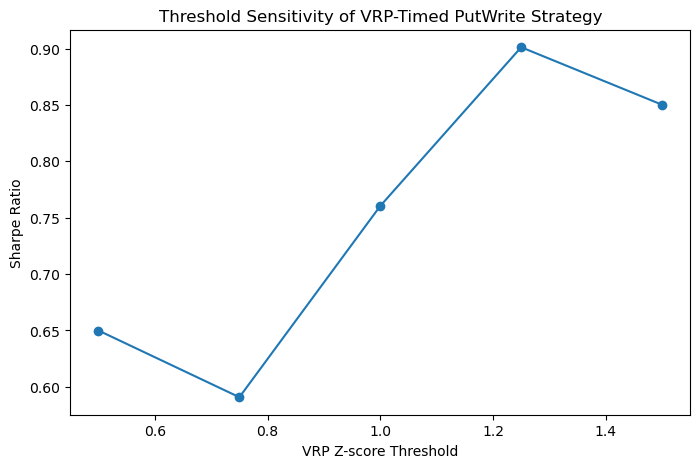

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Sharpe Ratio"],
    marker="o"
)

plt.xlabel("VRP Z-score Threshold")
plt.ylabel("Sharpe Ratio")
plt.title("Threshold Sensitivity of VRP-Timed PutWrite Strategy")

plt.show()

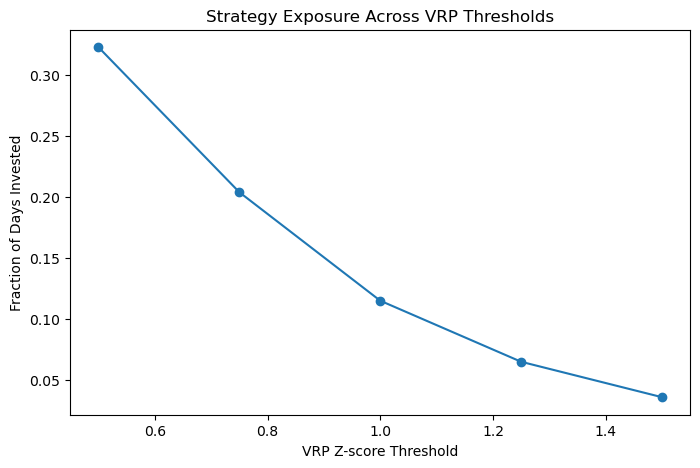

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Exposure"],
    marker="o"
)

plt.xlabel("VRP Z-score Threshold")
plt.ylabel("Fraction of Days Invested")
plt.title("Strategy Exposure Across VRP Thresholds")

plt.show()

## 10. Out-of-Sample Test

To reduce the risk of evaluating the strategy only on the same sample used to develop it, the final 30% of the backtest is treated as an out-of-sample holdout period.

The strategy specification is kept unchanged:

- 21-day realized volatility
- 252-day rolling VRP z-score
- Entry threshold of `z > 1`
- One-day lag between signal formation and exposure

No parameters are adjusted based on holdout-period performance.

In [50]:
split_idx = int(len(backtest) * 0.70)

development = backtest.iloc[:split_idx].copy()
holdout = backtest.iloc[split_idx:].copy()

print(
    "Development period:",
    development["date"].min(),
    "to",
    development["date"].max()
)

print(
    "Holdout period:",
    holdout["date"].min(),
    "to",
    holdout["date"].max()
)

Development period: 2017-10-04 00:00:00 to 2023-12-27 00:00:00
Holdout period: 2023-12-28 00:00:00 to 2026-09-02 00:00:00


In [51]:
oos_results = pd.DataFrame({
    "Development - PUT": performance_stats(
        development["put_return"]
    ),
    "Development - VRP": performance_stats(
        development["strategy_return"]
    ),
    "Holdout - PUT": performance_stats(
        holdout["put_return"]
    ),
    "Holdout - VRP": performance_stats(
        holdout["strategy_return"]
    )
})

oos_results

,Development - PUT,Development - VRP,Holdout - PUT,Holdout - VRP
Annualized Return,0.059438,0.054515,0.132744,0.049955
Annualized Volatility,0.145936,0.070868,0.101805,0.067596
Sharpe Ratio,0.407290,0.769244,1.303907,0.739021
Max Drawdown,-0.289256,-0.074322,-0.150605,-0.026544


In [52]:
development_exposure = development["position"].mean()
holdout_exposure = holdout["position"].mean()

print("Development exposure:", development_exposure)
print("Holdout exposure:", holdout_exposure)

Development exposure: 0.11224489795918367
Holdout exposure: 0.12202380952380952


### Out-of-Sample Interpretation

In the development period, the VRP-timed strategy improved the Sharpe ratio from approximately **0.41** to **0.77**, while substantially reducing maximum drawdown.

In the holdout period, the timing rule continued to reduce volatility and drawdown, with maximum drawdown falling from approximately **-15.1%** for continuous PutWrite exposure to **-2.7%** for the VRP-timed strategy.

However, the risk-adjusted performance advantage did not persist out of sample. The continuous PutWrite benchmark achieved a holdout Sharpe ratio of approximately **1.30**, compared with **0.74** for the VRP-timed strategy.

The holdout results therefore suggest that the timing rule's more robust benefit may be exposure and drawdown control rather than consistently superior risk-adjusted returns.

## 11. Subperiod Robustness

The sample is divided into two approximately equal subperiods to test whether the strategy's risk-adjusted improvement is concentrated in one market episode or persists across different periods.

In [53]:
split_date = backtest["date"].median()

first_half = backtest[backtest["date"] <= split_date].copy()
second_half = backtest[backtest["date"] > split_date].copy()

In [54]:
subperiod_results = pd.DataFrame({
    "First Half - PUT": performance_stats(first_half["put_return"]),
    "First Half - VRP": performance_stats(first_half["strategy_return"]),
    "Second Half - PUT": performance_stats(second_half["put_return"]),
    "Second Half - VRP": performance_stats(second_half["strategy_return"])
})

subperiod_results

,First Half - PUT,First Half - VRP,Second Half - PUT,Second Half - VRP
Annualized Return,0.069591,0.049037,0.092363,0.057268
Annualized Volatility,0.155405,0.079098,0.109057,0.059299
Sharpe Ratio,0.447804,0.619961,0.846924,0.965750
Max Drawdown,-0.289256,-0.074322,-0.160077,-0.035321


In [55]:
first_exposure = first_half["position"].mean()
second_exposure = second_half["position"].mean()

first_exposure, second_exposure

(np.float64(0.1125), np.float64(0.11785714285714285))

## 12. Conclusion

The analysis finds that unusually high volatility risk premium regimes are associated with stronger subsequent PutWrite returns.

Using a simple rule that holds the PutWrite strategy when the VRP z-score exceeds 1 reduced annualized return relative to continuous PutWrite exposure, but materially improved risk-adjusted performance and reduced drawdowns.

When idle capital is assumed to earn a 3-month Treasury return, the cash-adjusted strategy achieves an annualized return of approximately **7.76%**, with annualized volatility of approximately **6.98%** and maximum drawdown of approximately **-5.8%**. Under the notebook's return-to-volatility Sharpe calculation, this corresponds to a ratio of approximately **1.11**, compared with **0.60** for continuous PutWrite exposure.

The timing rule allocates to the PutWrite index on only about 11.5% of trading days, so reduced option exposure explains part of the lower risk. However, the strategy's Sharpe ratio exceeded approximately **94% of 1,000 randomly timed strategies with comparable exposure**, suggesting that the timing signal contributed information beyond simply reducing market participation.

Threshold-sensitivity, random same-exposure, subperiod, and temporal holdout tests provide a broader assessment of the strategy's robustness. While the VRP-timed strategy improved risk-adjusted performance in the development sample and in the earlier subperiod tests, this Sharpe-ratio advantage did not persist in the final 30% holdout period. The holdout strategy nevertheless continued to deliver materially lower volatility and drawdown.

Overall, the results suggest that the volatility risk premium may be useful as a regime-selection signal for controlling systematic option-selling exposure, particularly from a risk-management perspective. However, its ability to consistently improve risk-adjusted returns is less robust, and the findings remain sample-dependent.